In [111]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [117]:
%reload_ext autoreload

In [135]:
from data import build_all
from distances import compute_euclidean_distances, compute_mahalanobis_distances
from arsenal import compare_all_arsenals, arsenal_internal_distances
from biomech import evaluate_biomech_features, biomech_threshold_coverage
from stability import stability_analysis, plot_stability


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import pandas as pd
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings("ignore")

In [115]:
# import importlib
# import arsenal

# importlib.reload(arsenal)

In [ ]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

In [5]:
pitch_type_r.head()

,player_name,game_year,pitch_type,release_speed,pfx_x,pfx_z,n
0,"Wainwright, Adam",2021,CH,82.729744,-1.152821,0.643179,195
1,"Wainwright, Adam",2022,CH,82.182540,-1.192593,0.668889,189
2,"Wainwright, Adam",2023,CH,81.431461,-1.168652,0.729663,89
3,"Greinke, Zack",2021,CH,86.350791,-1.065747,0.371793,569
4,"Greinke, Zack",2022,CH,86.468984,-1.067433,0.317032,374


# Pitch Characteristics

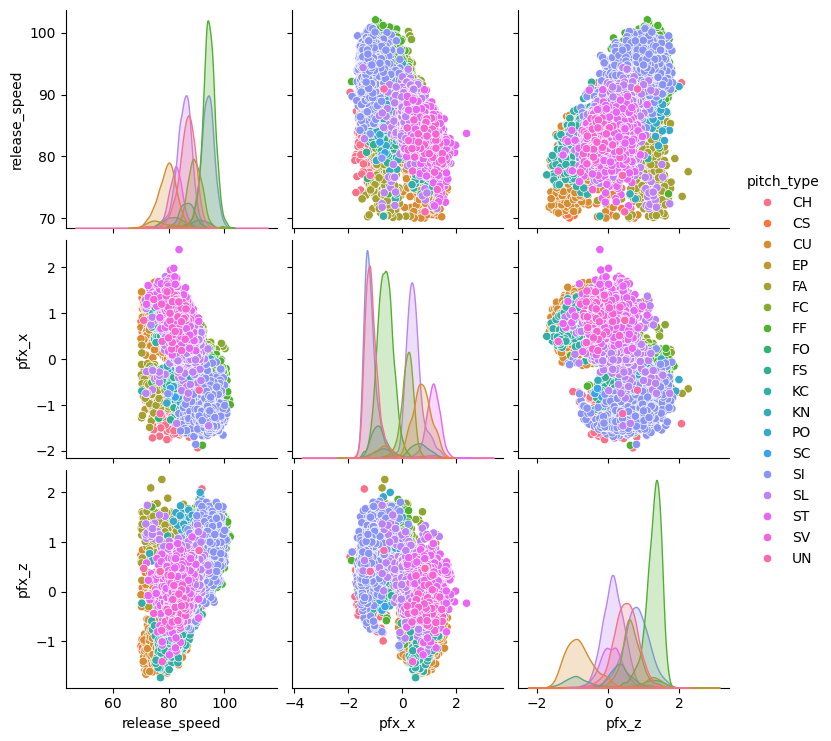

In [32]:
sns.pairplot(
    pitch_type_r,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
);

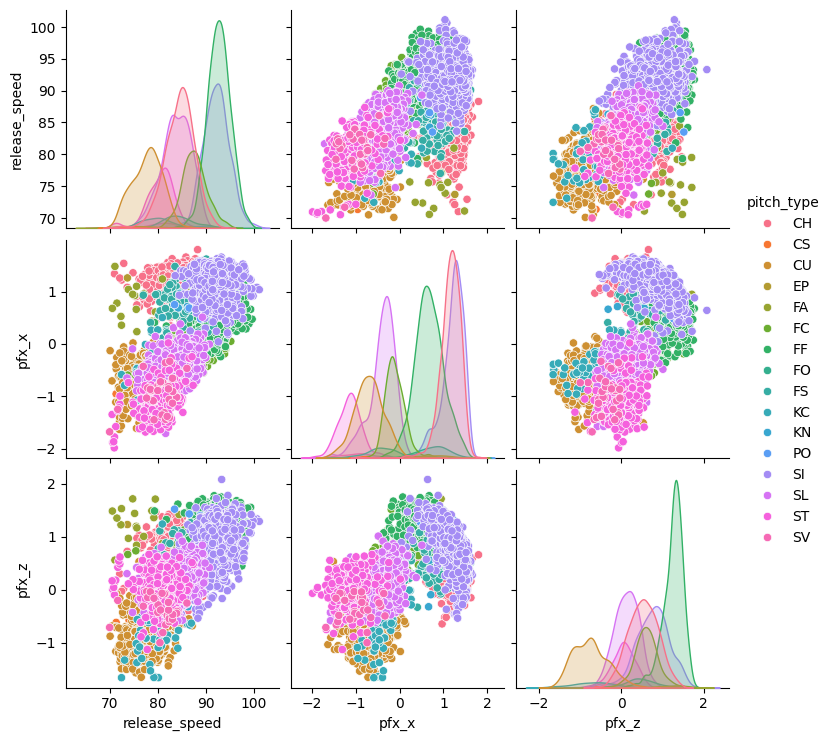

In [31]:
sns.pairplot(
    pitch_type_l,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
);

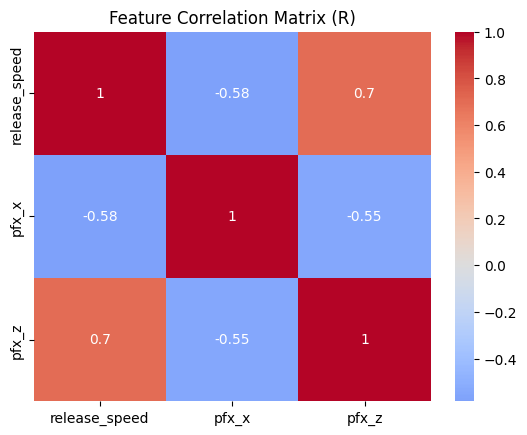

In [19]:
corr_r = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_r, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

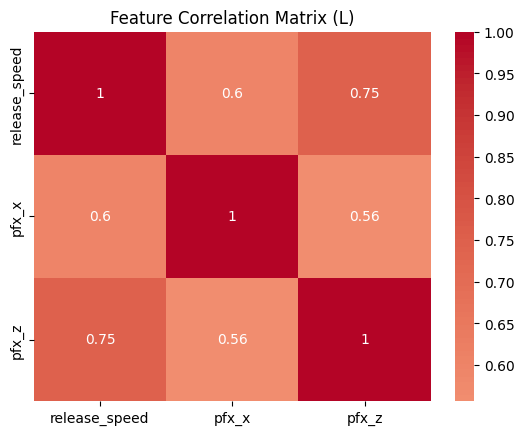

In [20]:
corr_l = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_l, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

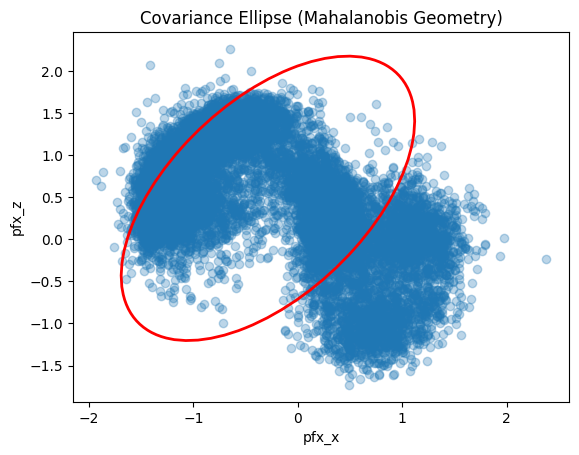

In [ ]:
X = pitch_type_r[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

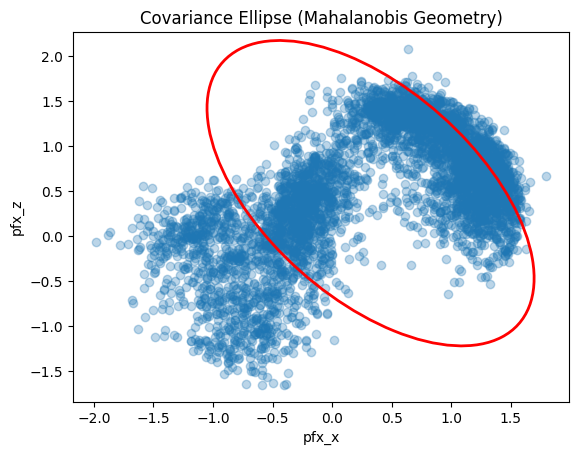

In [ ]:
X = pitch_type_l[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

In [26]:
X = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    0.025352
pfx_x            0.005542
pfx_z            0.006024
dtype: float64

In [27]:
X = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    1.714026
pfx_x            0.008860
pfx_z           -0.033997
dtype: float64

# Biomechanics Characteristics

In [34]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
2,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
3,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
4,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
5,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
6,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


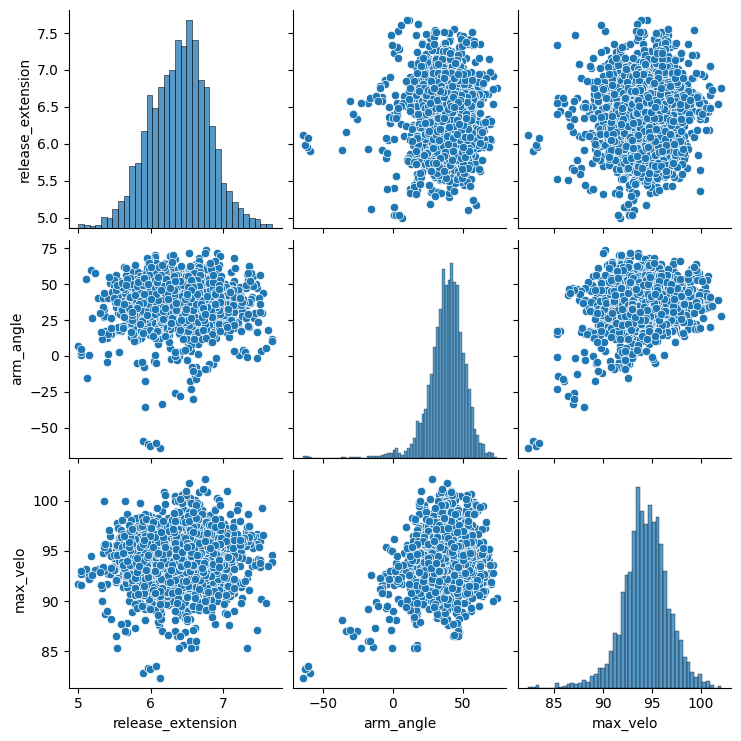

In [37]:
sns.pairplot(
    pitcher_summ_r[pitcher_summ_r['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

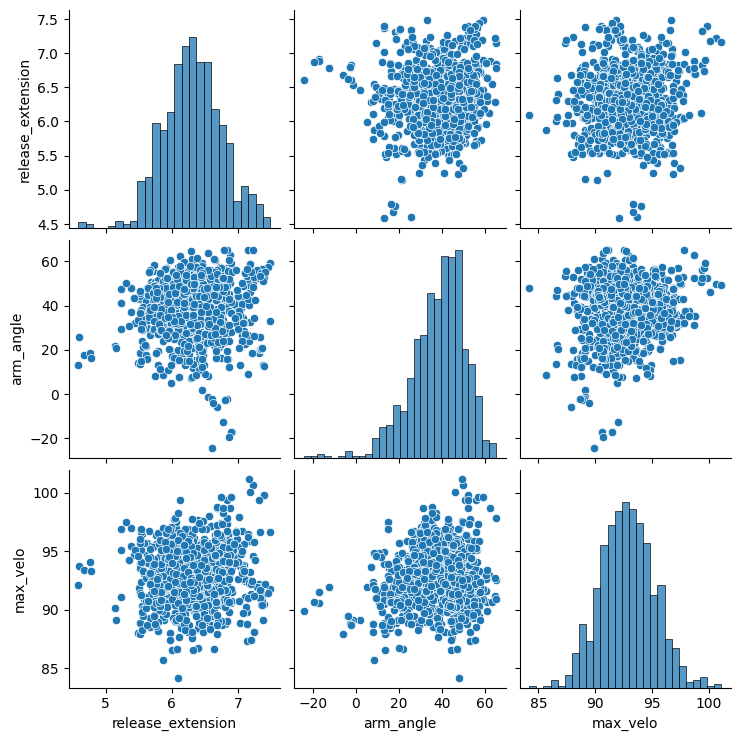

In [38]:
sns.pairplot(
    pitcher_summ_l[pitcher_summ_l['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

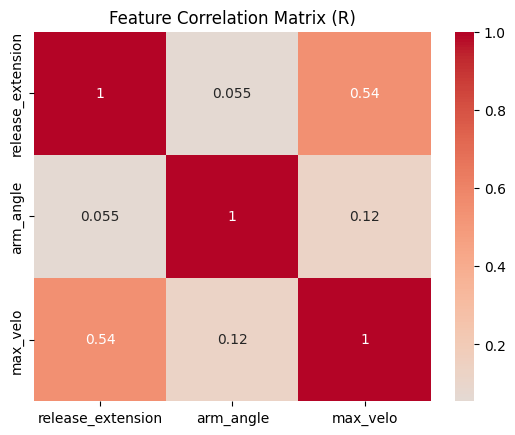

In [41]:
corr = pitcher_summ_r[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

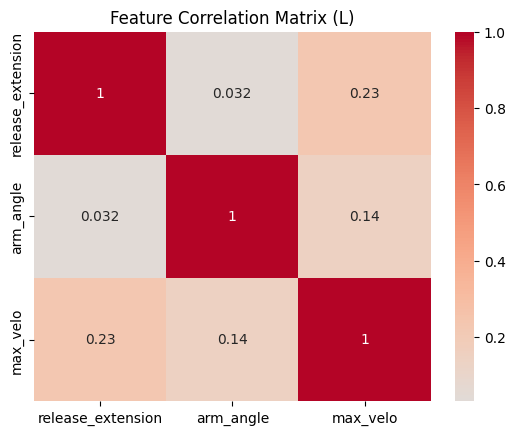

In [40]:
corr = pitcher_summ_l[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

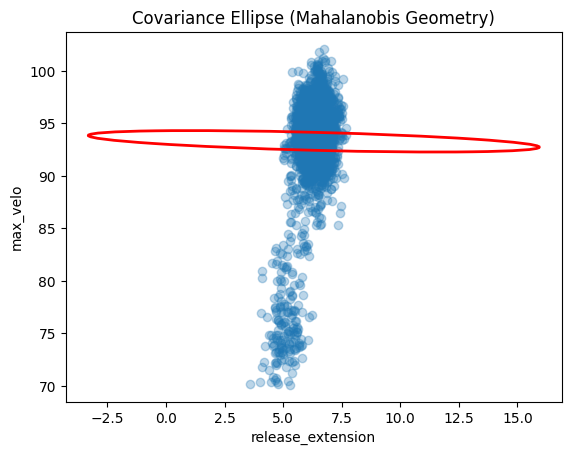

In [43]:
X = pitcher_summ_r[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

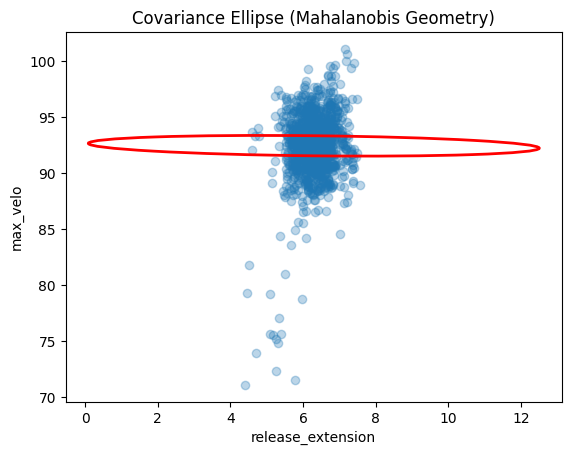

In [44]:
X = pitcher_summ_l[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

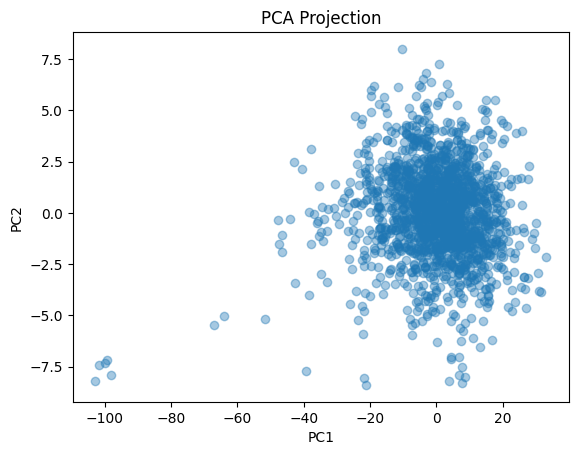

In [47]:
X = pitcher_summ_r[pitcher_summ_r['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

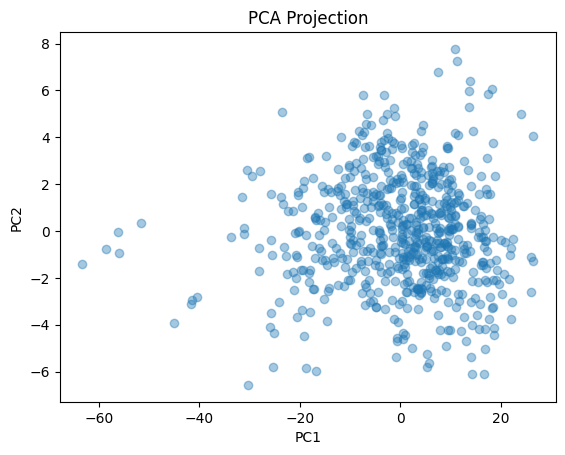

In [48]:
X = pitcher_summ_l[pitcher_summ_l['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

# Hyperparameter Optimization

## Data Prep

In [53]:
pitch_type_distance_r = compute_euclidean_distances(pitch_type_r, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)
pitch_type_distance_l = compute_euclidean_distances(pitch_type_l, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)

Filter to 2025 data only for practical purposes

In [55]:
pitch_type_distance_r_25 = pitch_type_distance_r[(pitch_type_distance_r['game_year1']==2025) & 
    (pitch_type_distance_r['game_year2']==2025)]
pitch_type_distance_l_25 = pitch_type_distance_l[(pitch_type_distance_l['game_year1']==2025) & 
    (pitch_type_distance_l['game_year2']==2025)]

In [63]:
arsenal_comp_l_25 = compare_all_arsenals(pitch_type_distance_l_25, 50)
arsenal_comp_r_25 = compare_all_arsenals(pitch_type_distance_r_25, 50)

2.013743173850861
2.0162059293092662


## Define Biomechanics

In [69]:
feature_sets = {
    'current (ext + arm_angle + max_velo + max_spin)':
       ['release_extension', 'arm_angle', 'max_velo', 'max_spin'],
    'current (ext + arm_angle + max_velo)':
       ['release_extension', 'arm_angle', 'max_velo'],
    'current (ext + arm_angle + max_velo + fb_pfx_x)':
       ['release_extension', 'arm_angle', 'max_velo', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + pri_fb_cd)':
        ['release_extension', 'arm_angle', 'max_velo', 'pri_fb_cd'],
    'current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_z', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'release_pos_z', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_z'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x', 'release_pos_z'],
}

In [64]:
pitcher_summ_r_25 = pitcher_summ_r[pitcher_summ_r['game_year']==2025]
pitcher_summ_l_25 = pitcher_summ_l[pitcher_summ_l['game_year']==2025]

In [80]:
results_r_euc = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("RHP:\n", results_r_euc.to_string(index=False))

results_l_euc = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("\nLHP:\n", results_l_euc.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3436      0.0   168490
                                            current (ext + arm_angle + max_velo + max_spin)        0.3521      0.0   168490
                                                       current (ext + arm_angle + max_velo)        0.3619      0.0   168490
            current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)        0.3624      0.0   166176
                            current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)        0.3652      0.0   166176
                            current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)        0.3751      0.0   166176
                                            current (ext + arm_angle + max_velo + fb_pfx_x)        0.3801      0.0   166176
cu

In [81]:
results_r_mah = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("RHP:\n", results_r_mah.to_string(index=False))

results_l_mah = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("\nLHP:\n", results_l_mah.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
            current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)        0.3015      0.0   166176
                            current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)        0.3205      0.0   166176
                            current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)        0.3225      0.0   166176
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3262      0.0   168490
current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)        0.3473      0.0   142311
                                            current (ext + arm_angle + max_velo + fb_pfx_x)        0.3504      0.0   166176
                                            current (ext + arm_angle + max_velo + max_spin)        0.3517      0.0   168490
  

**No matter how you slice it, extension, arm angle, max velocity, and active spin on the fastball are the best features to define biomechanics**

## Minimum Pitches Tuning

In [ ]:
stability_df_biomech, raw_biomech = stability_analysis(statcast_clean_25, 
                                                    ['release_extension', 'arm_angle'],
                                                    sample_sizes = ([5,10,15,20,25,30]),
                                                    n_replicates=100,
                                                    n_pitchers=100
                                                    )

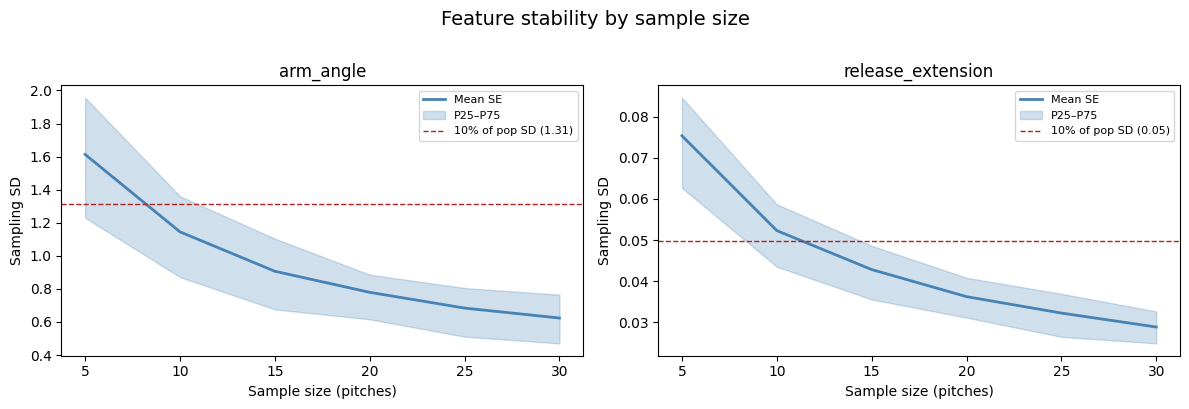

In [126]:
population_sds_biomech = {
    'arm_angle':         pitcher_summ['arm_angle'].std(),
    'release_extension': pitcher_summ['release_extension'].std(),
}
plot_stability(stability_df_biomech, population_sds_biomech)

In [127]:
stability_df_pitch, raw_pitch = stability_analysis(
    statcast_clean_25,
    features=['release_speed', 'pfx_x', 'pfx_z'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30]),
    n_replicates=100,
    n_pitchers=100
)

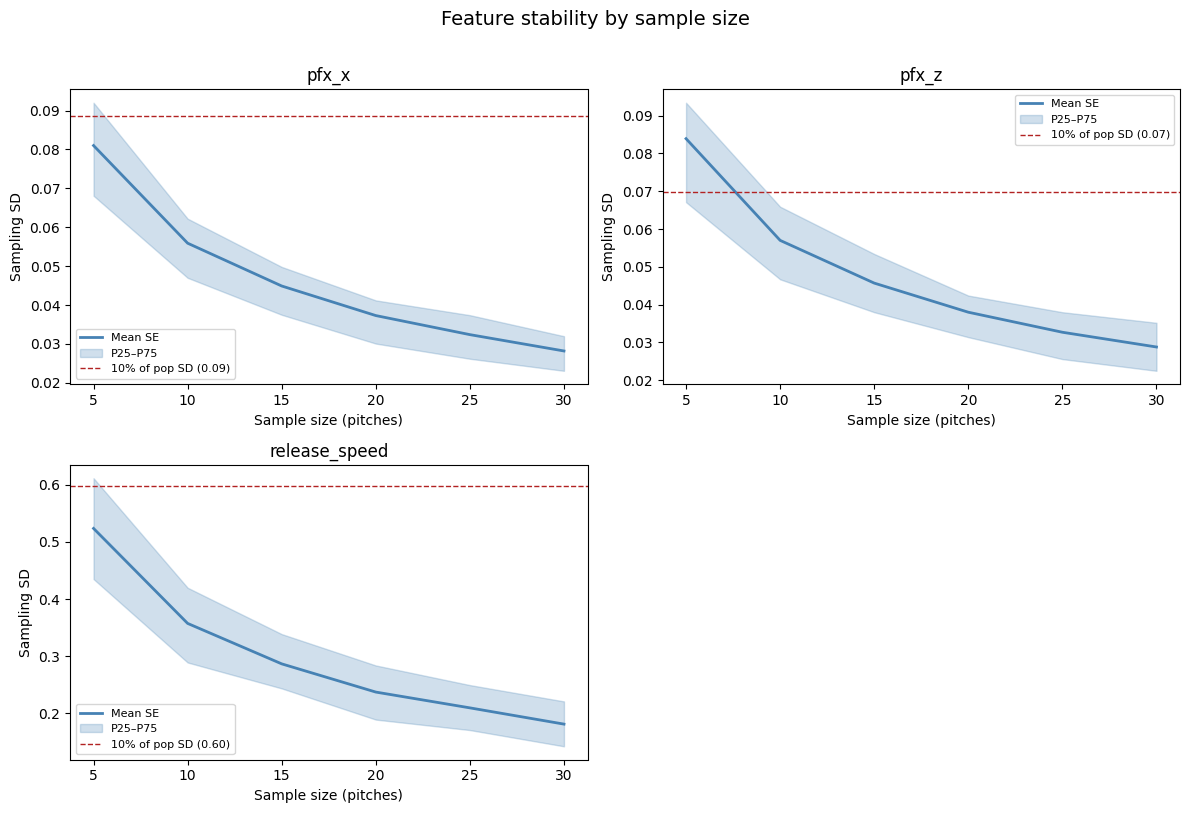

In [130]:
population_sds_pitch = {
    'release_speed': pitch_type_summ['release_speed'].std(),
    'pfx_x':         pitch_type_summ['pfx_x'].std(),
    'pfx_z':         pitch_type_summ['pfx_z'].std(),
}
plot_stability(stability_df_pitch, population_sds_pitch)

In [131]:
stability_df_pitch_ff, raw_pitch_ff = stability_analysis(
    statcast_clean_25[statcast_clean_25['pitch_type']=='FF'],
    features=['release_speed'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30,35,40]),
    n_replicates=100,
    n_pitchers=100
)

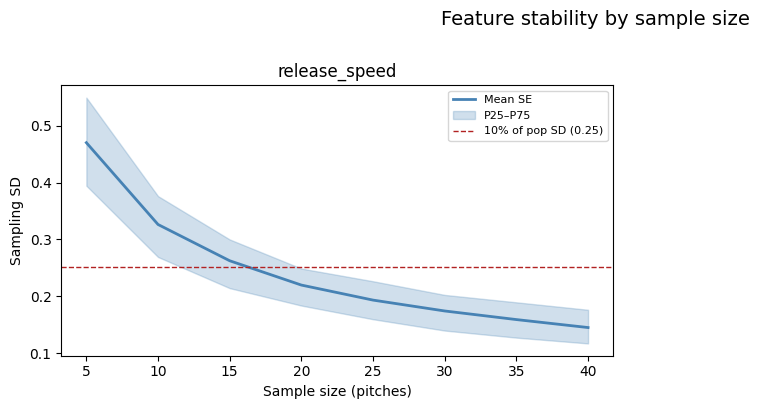

In [ ]:
pitch_type_summ_ff = pitch_type_summ[pitch_type_summ['pitch_type']=='FF']
population_sds_pitch_ff = {
    'release_speed': pitch_type_summ_ff['release_speed'].std()
}
plot_stability(stability_df_pitch_ff, population_sds_pitch_ff)

Both pitch characteristics and biomechanical features stabilize very quickly. The slowest feature to stabilize is fastball velocity, and even that is quite differentiable after 20 pitches. We will use 20 pitches as the minimum number of pitches for analysis going forward.

## Arsenal Minimum Distance

In [107]:
arsenal_df = arsenal_internal_distances(pitch_type_summ)

── Arsenal internal distances (across all pitcher-years) ──
       mean_min_dist  min_min_dist  p25_min_dist  p50_min_dist  p75_min_dist  p90_min_dist
count       3753.000      3753.000      3753.000      3753.000      3753.000      3753.000
mean           2.094         1.797         1.804         1.968         2.255         2.466
std            0.727         0.896         0.888         0.773         0.667         0.621
min            0.459         0.054         0.054         0.107         0.636         0.805
25%            1.556         1.121         1.127         1.427         1.779         2.013
50%            1.918         1.563         1.564         1.741         2.158         2.443
75%            2.464         2.292         2.292         2.296         2.571         2.880
max            3.464         3.464         3.464         3.464         3.464         3.464


Min_min_dist shows the minimum distance between any two pitches in an arsenal. For example, if a sinker and fastball are the two most similar pitches in an arsenal, their distance apart will be what goes into the min_min_dist. 

In contrast, the mean_min_dist calculates the mean of every pitch's closest neighbor (FF closest pitch, SI closest pitch, CH closest pitch, etc.)

Since the purpose of this evaluation is to define the minimum threshold for uniqueness to add to an arsenal, I will use the median min_min_dist of about 1.5 as a conservative estimate, meaning that if there is a suggestion for a new pitch, it must be at least as far from every pitch in the current arsenal as the median closest distance.

## Biomechanical Minimum Distance

In [178]:
cov_r = biomech_threshold_coverage(pitcher_summ_r, 
                                   thresholds=(1.0, 1.5, 2.0, 2.5),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
       1.0        58.1          0          3         42         98      21.6     26.4
       1.5       179.7          0         17        163        305      19.9     21.9
       2.0       342.8          0         65        376        566      19.2     20.4
       2.5       499.8          0        168        622        769      19.1     19.8


In [179]:
cov_l = biomech_threshold_coverage(pitcher_summ_l, 
                                   thresholds=(1.0, 1.5, 2.0, 2.5),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
       1.0        18.2          0          2         12         30      21.6     32.1
       1.5        57.5          0         10         47         95      19.3     22.4
       2.0       112.2          0         31        116        181      18.6     20.1
       2.5       169.3          0         77        203        262      18.3     18.8


Find examples of pitchers 1.5 apart


In [180]:
biomech_dist_l = compute_euclidean_distances(
    pitcher_summ_l,
    features=['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    label_cols=['player_name', 'game_year'],
    min_pitches=20,
)

In [182]:
biomech_dist_l[(biomech_dist_l['distance']>1.4999) & (biomech_dist_l['distance']<1.5001)]

,player_name1,player_name2,game_year1,game_year2,distance
69994,"Kay, Anthony","Davis, Austin",2021,2021,1.499902
69995,"Shreve, Chasen","Lucchesi, Joey",2021,2024,1.499902
69996,"Díaz, Jhonathan","Jay, Tyler",2021,2024,1.499912
69997,"Muller, Kyle","Hurter, Brant",2022,2025,1.499922
69998,"Hader, Josh","Cleavinger, Garrett",2022,2022,1.499924
69999,"Garrett, Braxton","Hughes, Brandon",2022,2024,1.499935
70000,"Hill, Rich","Waddell, Brandon",2025,2025,1.499959
70001,"Ray, Robbie","Allard, Kolby",2022,2022,1.499961
70002,"Price, David","Díaz, Jhonathan",2021,2021,1.499964
70003,"Kikuchi, Yusei","Mayza, Tim",2022,2025,1.499968
